In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded')

Libraries loaded


In [2]:
df = pd.read_csv('../data/raw/reviews_raw.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (2209, 8)
Columns: ['review_id', 'review_text', 'star_rating', 'date', 'app_id', 'app_category', 'category_label', 'category_name']


,review_id,review_text,star_rating,date,app_id,app_category,category_label,category_name
0,570b5412-5b91-48bb-8c06-963879515606,Android (Oxygen OS 16): home screen widget is ...,1,2026-06-16 18:22:10,com.todoist,productivity,0,Bug Report
1,515ec419-cce5-41da-aaff-5779f2031805,EDIT: I reached out to support as advised in t...,2,2026-06-16 16:36:06,com.todoist,productivity,1,Feature Request
2,75f42825-a30b-4237-9afe-c051a23b6e63,"not working on oneplus 9rt , can't login",1,2026-06-16 16:35:08,com.todoist,productivity,0,Bug Report
3,aa395a6b-07b5-422e-960e-e1317436b2ac,Yesterday I mentioned that a task disappeared ...,1,2026-06-16 03:31:49,com.todoist,productivity,0,Bug Report
4,41f403b4-c9a4-4bc3-bc29-756df20edac7,"Installed it, created an account, realized I n...",1,2026-06-15 19:18:12,com.todoist,productivity,2,UX Feedback


In [3]:
print('=== Dataset Overview ===')
print(f'Total reviews:     {len(df)}')
print(f'Unique apps:       {df["app_id"].nunique()}')
print(f'App categories:    {df["app_category"].nunique()}')
print(f'Missing values:\n{df.isnull().sum()}')
print(f'\nStar rating distribution:')
print(df['star_rating'].value_counts().sort_index())

=== Dataset Overview ===
Total reviews:     2209
Unique apps:       11
App categories:    5
Missing values:
review_id         0
review_text       0
star_rating       0
date              0
app_id            0
app_category      0
category_label    0
category_name     0
dtype: int64

Star rating distribution:
star_rating
1    860
2    190
3    166
4    156
5    837
Name: count, dtype: int64


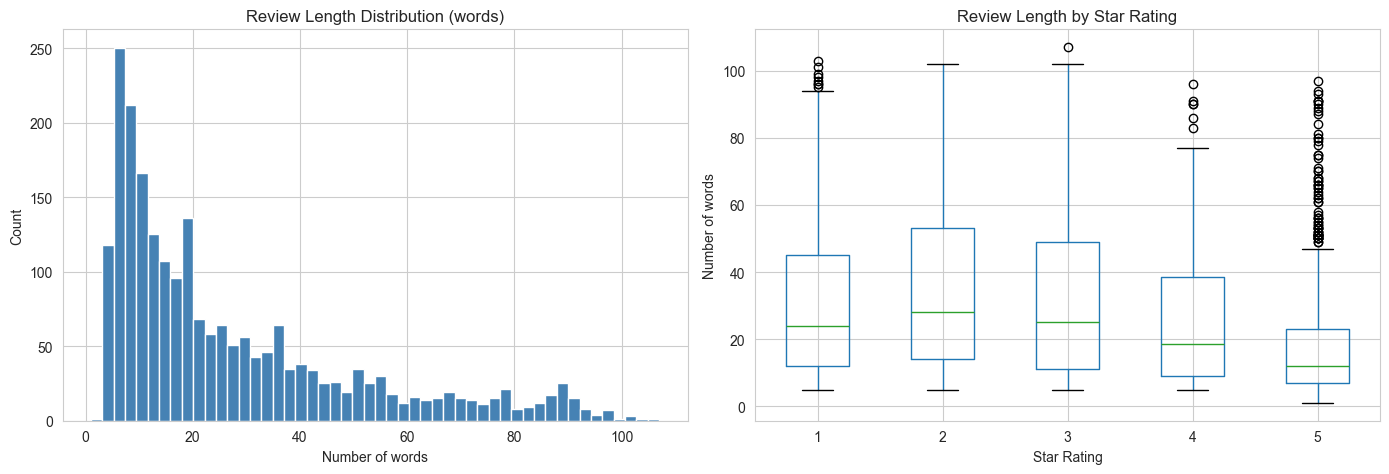

Average review length: 26.9 words
Median review length:  18.0 words
Max review length:     107 words


In [5]:
df['review_length'] = df['review_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['review_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Review Length Distribution (words)')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Count')

# Boxplot by star rating
df.boxplot(column='review_length', by='star_rating', ax=axes[1])
axes[1].set_title('Review Length by Star Rating')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Number of words')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../reports/review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Average review length: {df["review_length"].mean():.1f} words')
print(f'Median review length:  {df["review_length"].median():.1f} words')
print(f'Max review length:     {df["review_length"].max()} words')